# Exploratory Data Analysis
## Personalized Healthcare & Medicine Recommendation System

This notebook explores the two datasets that power the system:

1. **`disease_symptoms.csv`** — symptoms → disease (drives the disease-prediction model)
2. **`patient_profile.csv`** — symptoms + vitals → risk / outcome (drives the risk model)

A key goal of this EDA is to **justify the two-model design**: why each dataset is used for a different task.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / 'src'))
sns.set_theme(style='whitegrid')
RAW = Path.cwd().parent / 'data' / 'raw'
print('Datasets:', [p.name for p in RAW.glob('*.csv')])

Datasets: ['patient_profile.csv', 'disease_symptoms.csv']


---
## 1. Disease–Symptom dataset

In [2]:
dis = pd.read_csv(RAW / 'disease_symptoms.csv')
dis = dis.loc[:, ~dis.columns.str.startswith('Unnamed')].dropna(axis=1, how='all')
print('Shape:', dis.shape)
print('Number of symptoms (features):', dis.shape[1] - 1)
print('Number of diseases:', dis['prognosis'].nunique())
dis.head()

Shape: (4920, 133)
Number of symptoms (features): 132
Number of diseases: 41


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


Samples per disease: min = 120 , max = 120


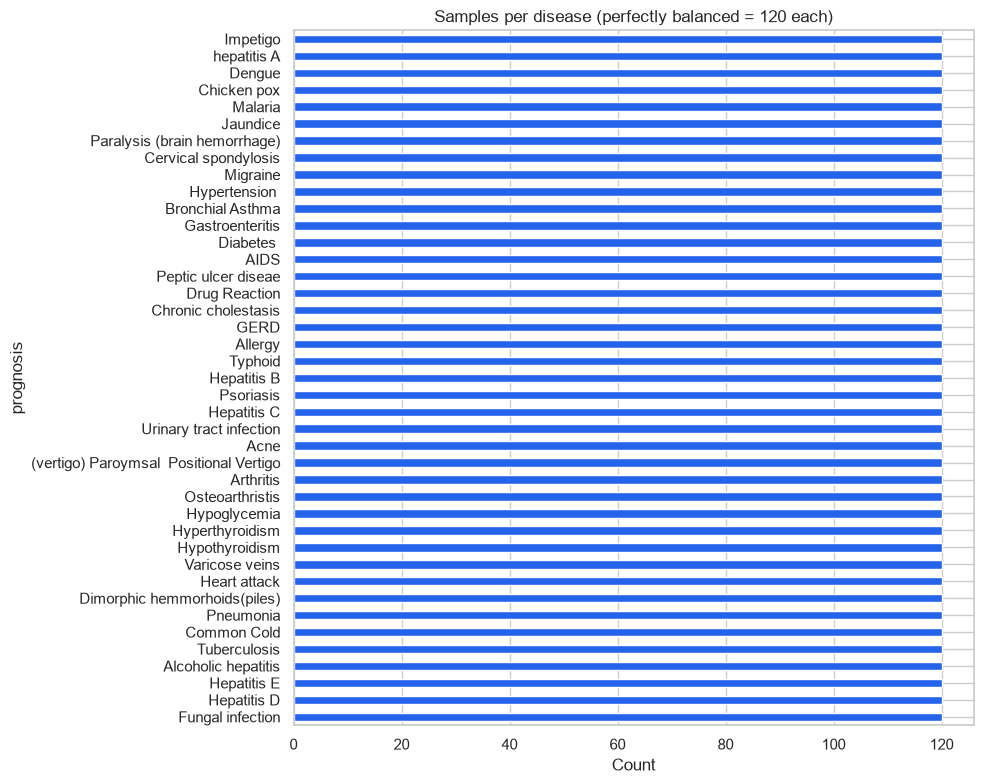

In [3]:
# Class balance — how many samples per disease?
counts = dis['prognosis'].value_counts()
print('Samples per disease: min =', counts.min(), ', max =', counts.max())
plt.figure(figsize=(10, 8))
counts.sort_values().plot(kind='barh', color='#2563eb')
plt.title('Samples per disease (perfectly balanced = 120 each)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

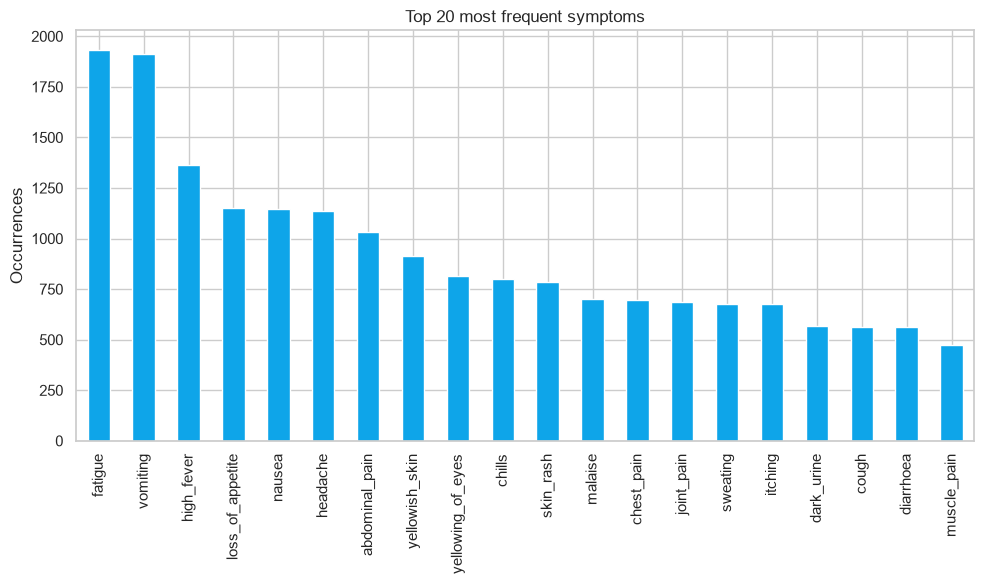

In [4]:
# Most common symptoms across all records
symptom_freq = dis.drop(columns='prognosis').sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
symptom_freq.head(20).plot(kind='bar', color='#0ea5e9')
plt.title('Top 20 most frequent symptoms')
plt.ylabel('Occurrences')
plt.tight_layout()
plt.show()

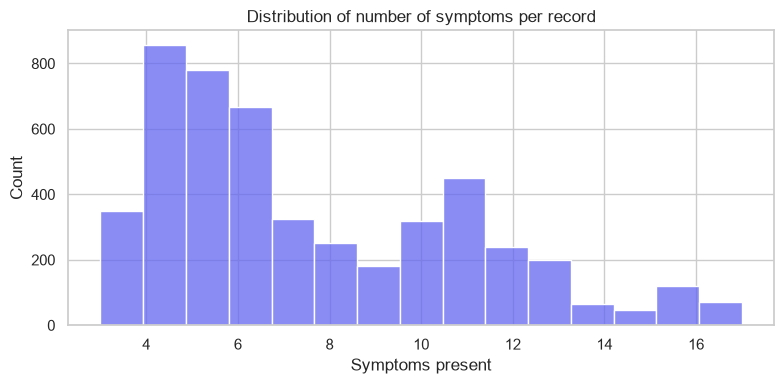

In [5]:
# How many symptoms does each disease typically present?
syms_per_disease = dis.drop(columns='prognosis').sum(axis=1)
plt.figure(figsize=(8, 4))
sns.histplot(syms_per_disease, bins=15, color='#6366f1')
plt.title('Distribution of number of symptoms per record')
plt.xlabel('Symptoms present')
plt.tight_layout()
plt.show()

**Takeaway:** This dataset is rich (132 symptoms) and balanced (120 samples each across 41 diseases). Each disease has a distinct symptom signature, which is why classifiers reach very high accuracy. → Ideal for the **disease-prediction model**.

---
## 2. Patient-Profile dataset

In [6]:
prof = pd.read_csv(RAW / 'patient_profile.csv')
print('Shape:', prof.shape)
print('Unique diseases:', prof['disease'].nunique())
print('Duplicate rows:', prof.duplicated().sum())
prof.head()

Shape: (349, 14)
Unique diseases: 116
Duplicate rows: 49


,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,Influenza,Yes,No,Yes,Yes,19,female,0,1,Positive,-2.091160,-2.419529,-0.576777,Low
1,Common Cold,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Low
2,Eczema,No,Yes,Yes,No,25,female,1,1,Negative,-1.631964,-0.723915,-0.576777,Medium
3,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium
4,Asthma,Yes,Yes,No,Yes,25,male,1,1,Positive,-1.631964,-0.723915,-0.576777,Medium


In [7]:
# THE KEY INSIGHT: only 4 symptom columns, but 100+ diseases.
symptom_cols = ['fever', 'cough', 'fatigue', 'difficulty_breathing']
combos = prof[symptom_cols].drop_duplicates()
print(f'Only {len(combos)} unique symptom combinations exist (max possible = 16)')
print(f'...but there are {prof["disease"].nunique()} diseases to distinguish.')
print('\n=> Predicting DISEASE from this dataset is infeasible (too few symptoms).')
print('=> Instead we predict a well-posed target: outcome / risk.')

Only 16 unique symptom combinations exist (max possible = 16)
...but there are 116 diseases to distinguish.

=> Predicting DISEASE from this dataset is infeasible (too few symptoms).
=> Instead we predict a well-posed target: outcome / risk.


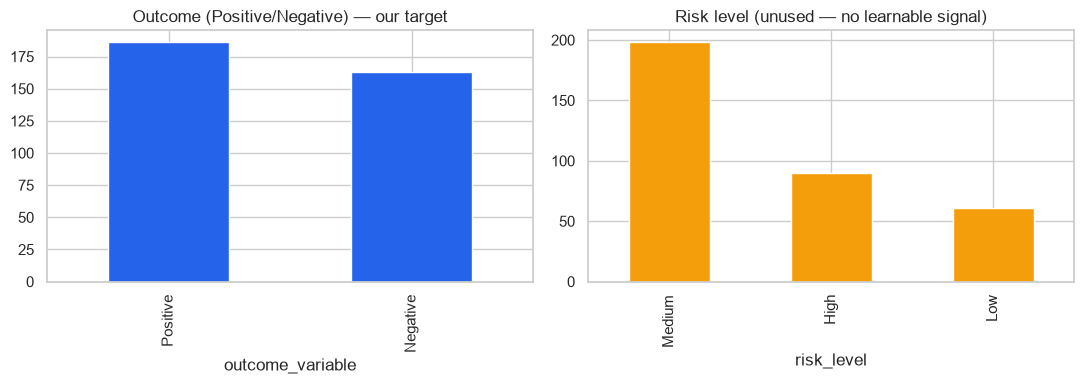

In [8]:
# Target distributions
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
prof['outcome_variable'].value_counts().plot(kind='bar', ax=axes[0], color='#2563eb')
axes[0].set_title('Outcome (Positive/Negative) — our target')
prof['risk_level'].value_counts().plot(kind='bar', ax=axes[1], color='#f59e0b')
axes[1].set_title('Risk level (unused — no learnable signal)')
plt.tight_layout()
plt.show()

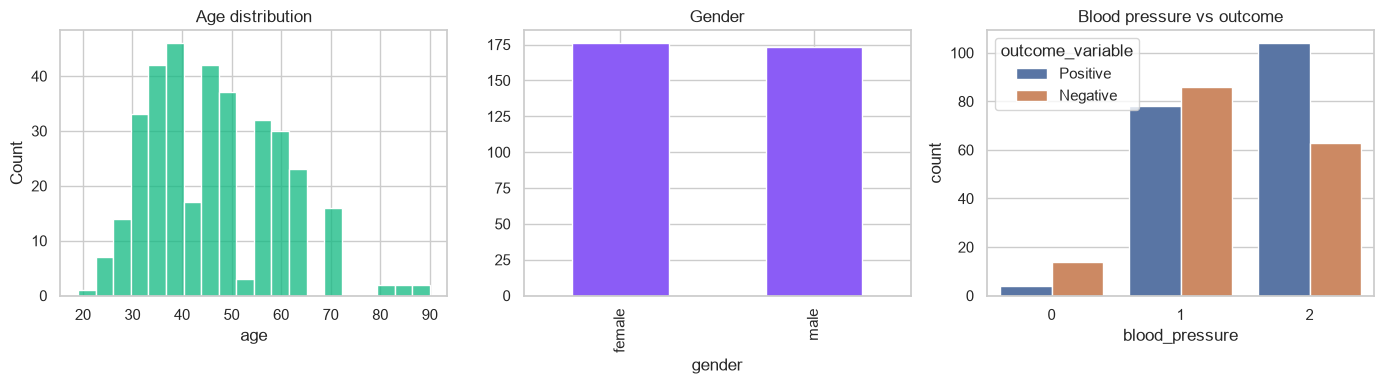

In [9]:
# Demographics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(prof['age'], bins=20, ax=axes[0], color='#10b981')
axes[0].set_title('Age distribution')
prof['gender'].value_counts().plot(kind='bar', ax=axes[1], color='#8b5cf6')
axes[1].set_title('Gender')
sns.countplot(data=prof, x='blood_pressure', hue='outcome_variable', ax=axes[2])
axes[2].set_title('Blood pressure vs outcome')
plt.tight_layout()
plt.show()

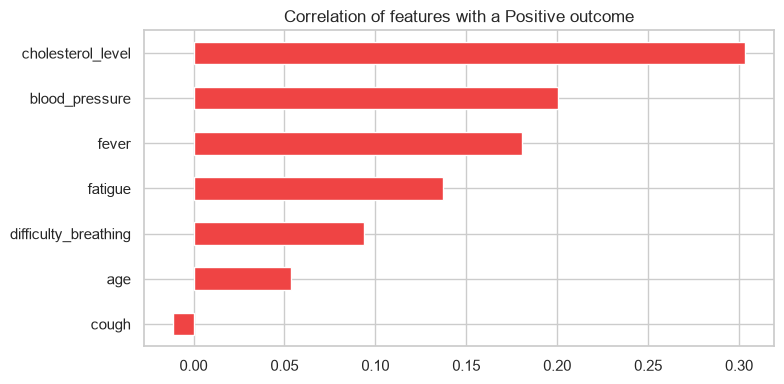

In [10]:
# Which features relate to a positive outcome?
tmp = prof.copy()
for c in symptom_cols:
    tmp[c] = (tmp[c].astype(str).str.lower() == 'yes').astype(int)
tmp['is_positive'] = (tmp['outcome_variable'] == 'Positive').astype(int)
corr = tmp[symptom_cols + ['age', 'blood_pressure', 'cholesterol_level', 'is_positive']].corr()['is_positive'].drop('is_positive')
plt.figure(figsize=(8, 4))
corr.sort_values().plot(kind='barh', color='#ef4444')
plt.title('Correlation of features with a Positive outcome')
plt.tight_layout()
plt.show()

---
## 3. Conclusions

| Dataset | Strength | Weakness | Used for |
|---------|----------|----------|----------|
| Disease–Symptom | 132 symptoms, balanced, separable | — | **Disease prediction** (100% acc) |
| Patient-Profile | rich vitals (age, BP, cholesterol) | only 4 symptoms, 116 diseases | **Risk/outcome screening** (~77% acc) |

**Design decision:** use each dataset for the task it can actually support, rather than forcing one dataset to do everything. This is the core rationale behind the two-model architecture.